# Autoencoders — Denoising (real training)

Train a small denoising autoencoder on sklearn digits (offline). Shows reconstructions.

_Last rebuild: **2026-02-16 03:48:35**_

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_digits

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams['figure.figsize']=(10,4)


In [2]:
digits = load_digits()
X = digits.data.astype('float32') / 16.0

# add gaussian noise
noise = np.random.normal(0, 0.35, X.shape).astype('float32')
X_noisy = np.clip(X + noise, 0.0, 1.0)

X_t = torch.tensor(X, dtype=torch.float32)
Xn_t = torch.tensor(X_noisy, dtype=torch.float32)

loader = DataLoader(TensorDataset(Xn_t, X_t), batch_size=128, shuffle=True)
X.shape

(1797, 64)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 16), nn.ReLU())
        self.dec = nn.Sequential(nn.Linear(16, 32), nn.ReLU(), nn.Linear(32, 64), nn.Sigmoid())
    def forward(self, x):
        return self.dec(self.enc(x))

model = AE().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(8):
    model.train(); losses=[]
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        out = model(xb)
        loss = loss_fn(out, yb)
        loss.backward(); opt.step()
        losses.append(loss.item())
    print('epoch', epoch+1, 'mse', float(np.mean(losses)))


epoch 1 mse 0.17603788475195567
epoch 2 mse 0.16564068297545115
epoch 3 mse 0.1409194787343343
epoch 4 mse 0.10279318938652675
epoch 5 mse 0.08290873616933822
epoch 6 mse 0.07742262333631515
epoch 7 mse 0.07450402081012726
epoch 8 mse 0.07294886161883672


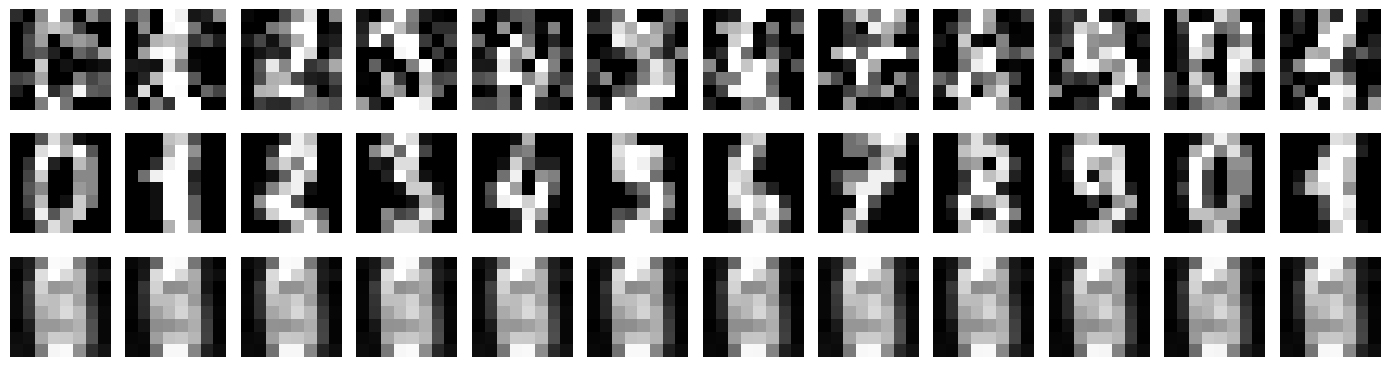

In [4]:
# visualize reconstructions
model.eval()
with torch.no_grad():
    sample = Xn_t[:12].to(device)
    recon = model(sample).cpu().numpy()

fig, axes = plt.subplots(3, 12, figsize=(14, 4))
for i in range(12):
    axes[0,i].imshow(X_noisy[i].reshape(8,8), cmap='gray'); axes[0,i].axis('off')
    axes[1,i].imshow(X[i].reshape(8,8), cmap='gray'); axes[1,i].axis('off')
    axes[2,i].imshow(recon[i].reshape(8,8), cmap='gray'); axes[2,i].axis('off')
axes[0,0].set_ylabel('noisy')
axes[1,0].set_ylabel('clean')
axes[2,0].set_ylabel('recon')
plt.tight_layout(); plt.show()

In [5]:
print('DONE 2026-02-16 03:48:35')

DONE 2026-02-16 03:48:35
